<a href="https://colab.research.google.com/github/asalasiniguez-a20s/analysis-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage

print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:'churn_date' tiene 88.35% de nulos, con más del 80–90%, así que ignorar o eliminar.

  'city' con 11.7% de nulos esta dentro de 5%–30%, imputar es viable.

   'date' tiene 0.125% de nulos, en esta columna hay que imputar.

   'duration' tiene 55.19% de nulos posiblemente por llamadas perdidas, sin conectar o marcaciones por error, ademas  si el servicio fue mensaje aparece como nulo, hay que dejar los datos tal cual.

   'length' tiene 44.74% de nulos y hay que dejar los datos como tal, ya que es un registro de llamada.
  
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print(users.describe())


            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` no veo algun indicador que levante alarma de un valor invalido o ssentinel.
- La columna `age` tiene un sentinel en mi de -999 y en std da resultado de 123 lo cual es improbable sea real.

In [ ]:
# explorar columnas numéricas de usage
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`veo todo en orden, no hay valor invalido o sentinels.
- Las columnas `duration` y `length`: 'duration' si tiene sentido ya que puede ser una llamada sin contestar o un valor nan por se un mensaje y en 'length' el min pudo ser un valor nan por ser llamada, a su vez en 'length el maximo si puede ser un valor valido.


In [ ]:
#explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columnas_users in ['city', 'plan']:
    print(users[columnas_users].value_counts())


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` tiene un valor centinel '?' este valor hay que imputarlo por NA o eliminarlo.
- La columna `plan` dice cuantos usuarios tienen plan basico y premium.

In [ ]:

# explorar columna categórica de usage

columnas_usages = ['type']
for columnas_usage in columnas_usages:
    print(usage[columnas_usage].value_counts())




text    22092
call    17908
Name: type, dtype: int64


- La columna `type` solo contiene los valores esperados: text y call. No se detectaron valores inválidos ni sentinels.


---
✍️
 **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  en la coluna `city` hay sentinel '?', y en `age` un sentinel "-999"
- ¿Qué acción tomarías?  
Usar la mediana para `age` es ideal porque es robusta frente a valores extremos como -999, y eliminar las filas con "?" en `city` es razonable dado que son solo 96 registros de 4000.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:


# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')



In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, veo 1330 registros del año 2024, 1316 registros del 2023 y 1314 del 2022, tambien 40 regsitros del 2026 los cuales son valores invalidos.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()


2024.0    39950
Name: date, dtype: int64

En `date` veo que en el año 2024 hay 39950 registros lo cual parece todo en orden.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) si, aparece el año 2026
- ¿Qué harías con ellas? usar una asignacion que remplace esa fecha con pd.NaT

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users.loc[users['age']== -999, 'age'] = age_mediana



# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:


# Reemplazar ? por NA en city
users.loc[users['city']== '?', 'city'] = pd.NA
# Verificar cambios
users['city'].describe()


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year== 2026, 'reg_date'] = pd.NaT

# Verificar cambiosusers.lo
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

 diagnostico de nulos en `duration` y `length` dependen de type, ya que si el registro es llamada o mensaje `type` lo determina, por ende no hay que eliminar esos datos

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario

usage_agg = usage.groupby("user_id").agg({

    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum",
 }).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg.rename(columns={"is_text": "cant_mensajes", "is_call":"cant_llamadas", "duration":"cant_minutos_llamada"}, inplace=True)
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,48.138285,5.524381,4.478120,23.317054
std,1154.898108,17.691541,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.500000,33.000000,4.000000,3.000000,11.120000
50%,12000.000000,48.000000,5.000000,4.000000,19.780000
75%,12999.500000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

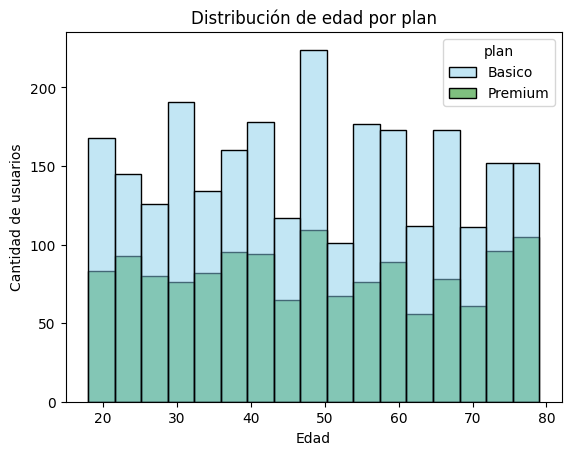

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title("Distribución de edad por plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights:
- Distribución de edad por plan demuestra que la distribucion es simetrica, que el plan basico es mas solicitado por personas entre 45 y 50 años, teniendo mas de 100 clientes por edades; mientras que el plan premium tiene generalmente registros por edades menores a 100 usuarios, lo recomendado es hacer mayor publicidad para el plan premium en todas las edades para subir la cantida de usuarios.

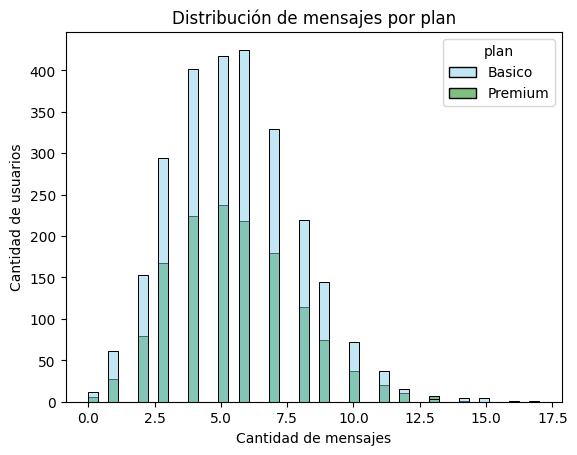

In [ ]:
# Histograma para visualizar la cant_mensajes


sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title("Distribución de mensajes por plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()



💡Insights:
- distribución de mensajes por plan demuestra que hay un sesgo a la derecha en ambas categorias lo cual significa que la mayoria de usuarios manda 5 mensajes, siendo el plan basico mas de 400 usuarios que mandan mas de 5 mensajes y en el plan premiummenos de 250 personas mandan ese promedio.  la empresa puede implementar campañas de fidelizacion y premios para que usen mas el servicio de mensajes en ambos planes.

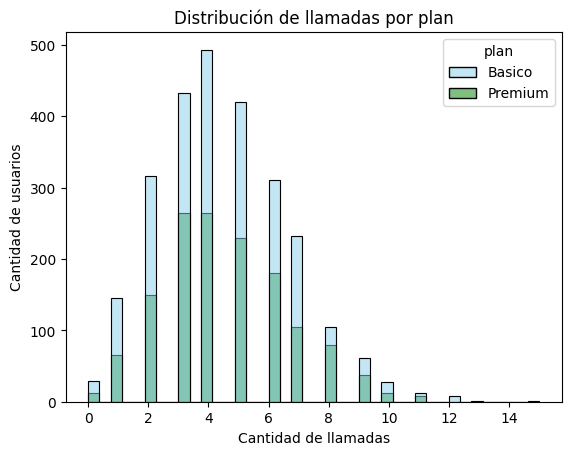

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title("Distribución de llamadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights:
- Distribución de llamadas tiene un sesgo a la derecha en ambos planes, los usuarios de plan basico y premium hacen entre 2 y 7 llamadas, siendo mas de 300 usuarios en el plan basico los que hacen esa cantidad de llamadas por plan y los de plan premium son menos de 300 usuarios los que hacen llamadas entre 2 y 7. lo recomendable es hacer campañas de promocion en llamadas y premios a quienes hagan mas de 10 llamadas en plan premium, a los usuarios de plan basico invitarlos a subir a plan premium.

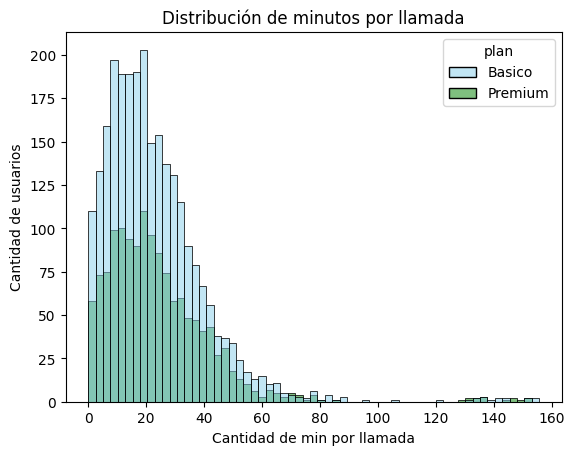

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title("Distribución de minutos por llamada")
plt.xlabel("Cantidad de min por llamada")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights:
- minutos por llamada demuestra que hay un sesgo a la derecha, los usuarios de ambos planes usan menos de 40 minutos por llamada concentrandose entre 0 y 40 minutos. la recomendscion seria ofrecer a los clientes con mayor uso de minutos planes mas personalizados  que les haga mas satisfaccion.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

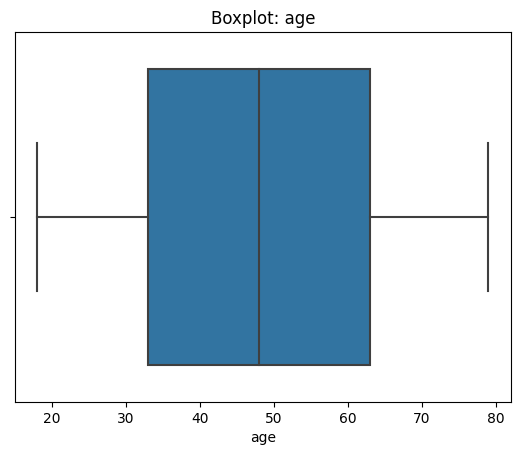

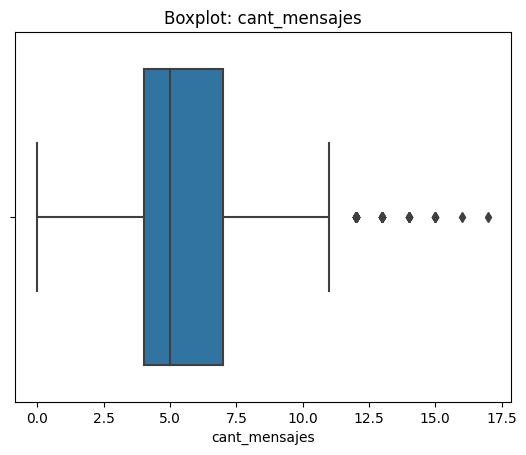

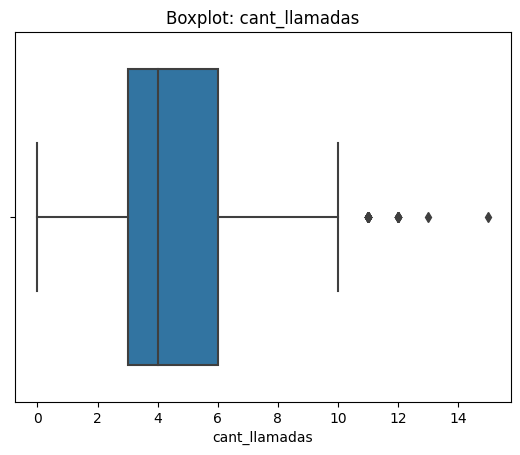

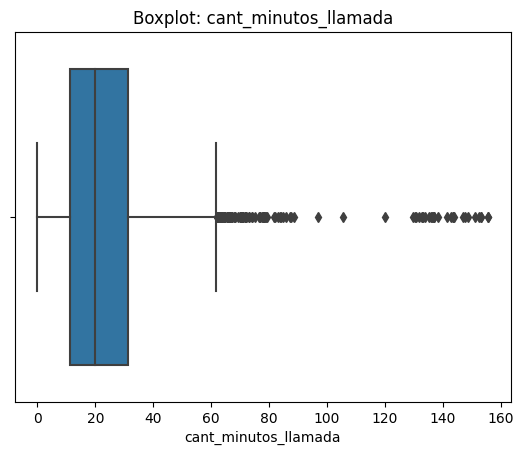

In [ ]:
# Visualizando usando BoxPlot

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights:
- Age: ´age´ muestra que no hay outliers, el Q3 es 63 años, el Q1 es 33 años, el extremo inferior es de 18 años, el Q4 es de 79 años y el Q2 es de 48años
- cant_mensajes: ´cant_mensajes´ si presenta 6 puntos outliers del lado derecho, lo cual indica que son valores altos, el extremo inferior es 0, el Q1 son 4 mensajes, el Q2 5 mensajes, el Q3 7 mensajes y el bigote superior es 11, el valor atipico extremo es 17 mensajes.
- cant_llamadas: ´cant_llamadas´ presenta 4 puntos outliers del lado derecho, lo cual indica que son valores altos, el extremo inferior es 0, el Q1 son 3 llamadas, el Q2 4 llamadas, el Q3 6 llamadas y el bigote superior es 10 llamadas, el valor atipico extremo es 15 llamadas.
- cant_minutos_llamada: ´cant_minutos_llamada´ tambien presenta multiples puntos outliers del lado derecho, lo cual indica que son valores altos, el extremo inferior es 0, el Q1 son 11.12 minutos, el Q2 19.78 minutos, el Q3 31.41 minutos y el bigote superior es 60 minutos, el valor atipico extremo es 155.60 minutos.

Columna: cant_mensajes, Limite_superior: 11.5
      user_id first_name last_name   age      city  \
315     10315     Carlos     Lopez  30.0       MTY   
347     10347     Carlos    Garcia  77.0      Cali   
356     10356      Mateo    Garcia  42.0      CDMX   
384     10384      Sofia   Ramirez  35.0      CDMX   
456     10456      Mateo   Ramirez  48.0      CDMX   
539     10539      Sofia   Ramirez  77.0      Cali   
591     10591        Ana     Gomez  25.0       NaN   
670     10670     Carlos    Torres  47.0    Bogotá   
903     10903     Carlos     Lopez  63.0      CDMX   
908     10908    Mariana     Lopez  56.0       MTY   
987     10987      Mateo   Ramirez  30.0       GDL   
1054    11054      Mateo     Lopez  72.0      Cali   
1158    11159    Mariana    Torres  79.0    Bogotá   
1172    11173      Sofia    Torres  37.0    Bogotá   
1196    11197     Carlos    Torres  48.0       GDL   
1254    11255      Sofia     Lopez  71.0       NaN   
1281    11282      Mateo     Gomez  

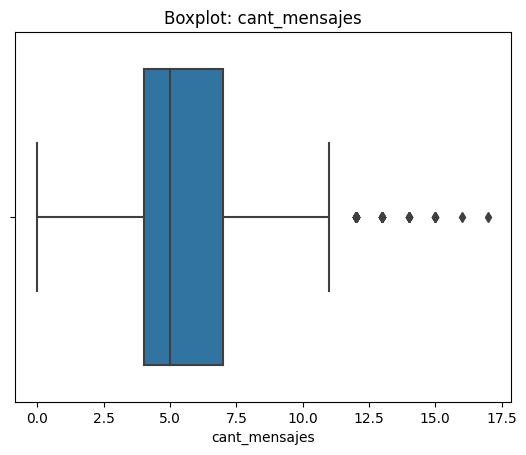

Columna: cant_llamadas, Limite_superior: 10.5
      user_id first_name last_name   age      city  \
116     10116        Ana    Garcia  52.0      CDMX   
417     10417       Luis    Garcia  70.0    Bogotá   
777     10777      Sofia     Lopez  65.0      Cali   
778     10778      Mateo     Lopez  77.0       NaN   
862     10862       Luis   Ramirez  23.0    Bogotá   
1013    11013      Mateo     Lopez  65.0      CDMX   
1563    11564     Carlos     Lopez  41.0      CDMX   
1613    11614      Mateo    Garcia  73.0    Bogotá   
1911    11912    Mariana    Garcia  48.0  Medellín   
2012    12013      Mateo     Lopez  48.0       GDL   
2097    12098     Carlos    Torres  39.0      Cali   
2200    12201     Carlos     Gomez  66.0      CDMX   
2219    12220        Ana     Lopez  50.0       NaN   
2224    12225     Carlos   Ramirez  32.0       GDL   
2274    12275      Mateo    Garcia  35.0      Cali   
2491    12492     Carlos    Torres  58.0    Bogotá   
2510    12511      Sofia    Garcia  

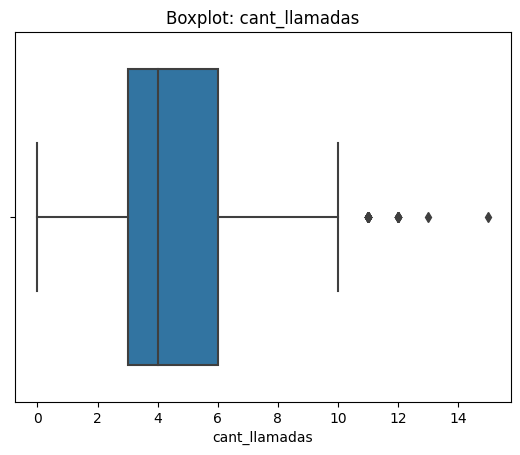

Columna: cant_minutos_llamada, Limite_superior: 61.8575
      user_id first_name last_name   age      city  \
27      10027        Ana     Gomez  28.0       MTY   
85      10085     Carlos   Ramirez  65.0       GDL   
93      10093        Ana    Torres  67.0  Medellín   
189     10189    Mariana    Torres  63.0       MTY   
198     10198      Sofia     Gomez  58.0  Medellín   
...       ...        ...       ...   ...       ...   
3919    13920    Mariana     Lopez  48.0    Bogotá   
3926    13927    Mariana     Lopez  18.0       GDL   
3944    13945       Luis   Ramirez  30.0    Bogotá   
3952    13953      Mateo     Gomez  58.0       GDL   
3966    13967     Carlos    Torres  72.0  Medellín   

                          reg_date     plan   churn_date  cant_mensajes  \
27   2022-01-08 09:26:03.690922730  Premium          NaN              8   
85   2022-01-24 06:35:22.730682670   Basico          NaN              6   
93   2022-01-26 11:09:46.046511628   Basico          NaN              

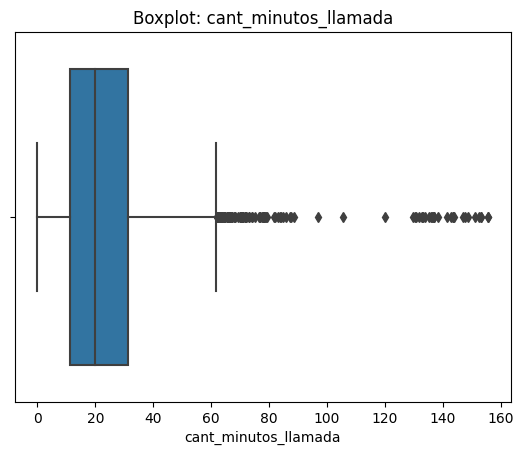

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']



for col in columnas_limites:
     Q1 = user_profile[col].quantile(0.25)
     Q3 = user_profile[col].quantile(0.75)
     IQR = Q3 - Q1
     upper = Q3 + 1.5 * IQR
     print(f'Columna: {col}, Limite_superior: {upper}')
     print(user_profile[(user_profile[col] > upper)])
     sns.boxplot(data=user_profile, x=col)
     plt.title(f'Boxplot: {col}')
     plt.show()





In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000



💡Insights:

- cant_mensajes: Si tiene 6 outliers los cuales hay que mantener por que el maximo es 17 mensajes, lo cual es un volor posible en la vida real

- cant_llamadas: tambien tiene en total 4 outliers y hay que mantenerlos, elmaximo es de 15 llamadas y es un comportamiento posible en usuarios.

-
- cant_minutos_llamada: tiene mas outliers 109 en total, los que si hay que mantener ya que el maximo es de 155 min lo cual si puede ser un dato real.




---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso

import numpy as np

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),  # Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
]

valores = ['Bajo uso', 'Uso medio']
default = 'Alto uso'
user_profile['grupo_uso'] = np.select(condiciones, valores, default= 'Alto uso')


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

import numpy as np

condiciones = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

valores = ['Joven', 'Adulto']
default = 'Adulto Mayor'
user_profile['grupo_edad'] = np.select(condiciones, valores, default= 'Adulto Mayor')


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

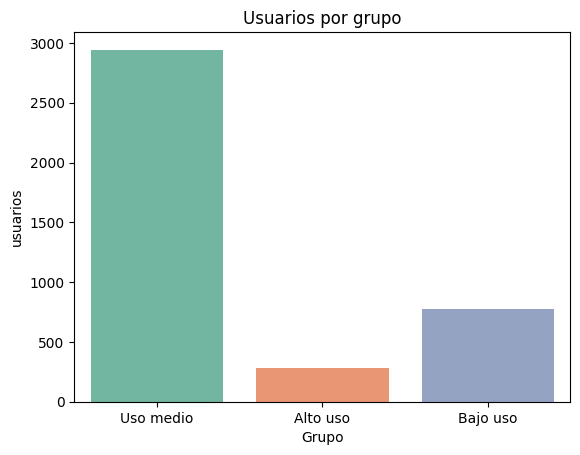

In [ ]:
# Visualización de los segmentos por uso


sns.countplot(data=user_profile, x='grupo_uso', palette='Set2')
plt.title("Usuarios por grupo")
plt.xlabel("Grupo")
plt.ylabel("usuarios")

plt.show()



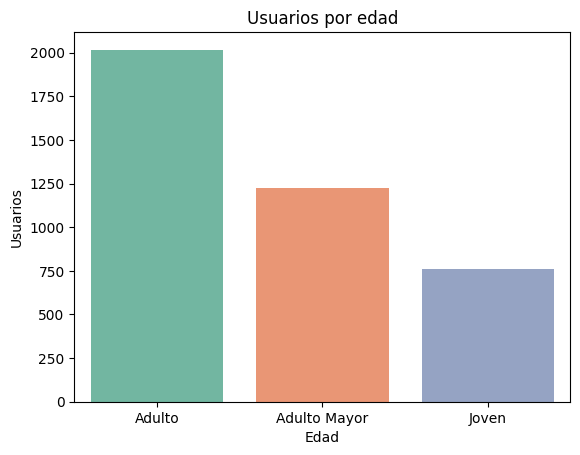

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='Set2')
plt.title("Usuarios por edad")
plt.xlabel("Edad")
plt.ylabel("Usuarios")

plt.show()


In [ ]:
(user_profile['grupo_uso'].value_counts(normalize=True) * 100).round(2)


Uso medio    73.59
Bajo uso     19.45
Alto uso      6.95
Name: grupo_uso, dtype: float64

In [ ]:
(user_profile['grupo_edad'].value_counts(normalize=True) * 100).round(2)

Adulto          50.44
Adulto Mayor    30.56
Joven           19.00
Name: grupo_edad, dtype: float64


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.


**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos? ¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**


- La columna ´age´ contenía un sentinel (-999) que fue reemplazado por la mediana para no distorsionar el análisis

- ´churn_date´ contenia 88.35% de valores nulos. Se conservaron al representar clientes que no han cancelado el servicio.

- ´city´ tenia 11.7% de valores nulos. Se trataron los registros faltantes para evitar sesgos en el análisis.

- ´date´ presentaba 0.125% de valores nulos y se eliminaron o imputaron debido a su baja proporción.

- ´duration´ tenia 55.19% de valores nulos. Se mantuvieron al corresponder a llamadas sin duración o servicios de mensajería.

- ´length´ daba como resultado 44.74% de valores nulos, se conservaron al no aplicar para determinados tipos de interacción.

- ´reg_date´ mostraba 40 fechas inválidas (2026)las cuales se eliminaron o corrigieron por ser fechas imposibles dentro del periodo analizado.



🔍 **Segmentos por Edad**
- Adulto          50.44% de los usuarios.
- Adulto Mayor    30.56% de los usuarios.
- Joven           19.00% de los usuarios.

La mayor parte de la base de clientes se concentra en el segmento de Adulto (50.44%), lo que indica que este grupo representa el mercado objetivo principal de la empresa y ofrece la mayor oportunidad para implementar estrategias

📊 **Segmentos por Nivel de Uso**
- Uso medio: 73.59% de los usuarios.
- ⁠Bajo uso: 19.45% de los usuarios.
- ⁠Alto uso: 6.95% de los usuarios.
  
La mayor parte de la base de clientes se concentra en el segmento de uso medio, lo que indica que existe una base estable de usuarios que utilizan el servicio con frecuencia moderada.

➡️ Esto sugiere que existe un alto potencial para convertir clientes de uso medio en clientes de alto uso mediante campañas de fidelización, promociones personalizadas y recomendaciones de planes que se adapten a sus patrones de consumo. Incluso migrar un pequeño porcentaje de este segmento podría generar un impacto positivo en los ingresos y en el valor de vida del cliente.

los patrones de uso extremo fueron los siguientes outliers:
- cant_mensajes:46 usuarios
- cant_llamadas:30 usuarios
- cant_minutos_llamada:109 usuarios

Estos clientes representan principalmente una oportunidad de negocio, ya que son candidatos ideales para estrategias de crecimiento a planes Premium o planes con mayores beneficios. Además de incrementar el ingreso promedio por usuario, un plan más adecuado podría mejorar su satisfacción al reducir cargos por excederce.
Los 109 usuarios con consumo extremo de minutos estan en un segmento pequeño pero de alto valor comercial. Aunque su tamaño es reducido, su nivel de consumo los convierte en un grupo prioritario para implementar estrategias de retención y migración a planes de mayor valor.
sin embargo si los costos por excedentes son percibidos como elevados, estos clientes podrían cambiar de operador o cancelar el servicio. Por ello, es importante ofrecerles alternativas antes de que esto ocurra.


💡 **Recomendaciones**
- Identificar a los clientes que exceden con frecuencia los beneficios de su plan.
- ⁠Diseñar campañas de upselling para migrarlos a planes Premium o con mayor capacidad.
- ⁠Ofrecer beneficios exclusivos para fidelizar a este segmento de alto consumo.
- ⁠Analizar si existe demanda para crear un plan de alto consumo que se ajuste mejor a sus necesidades.



---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`